In [ ]:
# Подключаем библиотеки
import pandas as pd # Работа с набором данных
import numpy as np # Линейная алгебра
# Визуализация данных
import seaborn as sns
import matplotlib.pyplot as plt

# отключение информационных сообщений
from warnings import filterwarnings
filterwarnings(action='ignore')

In [ ]:
# читаем данные
url = 'https://raw.githubusercontent.com/yakushinav/omo/refs/heads/main/data/Data_User_Modeling_Dataset.csv'
data = pd.read_csv(url)
data.head(5)

,STG,SCG,STR,LPR,PEG,UNS
0,0.00,0.00,0.00,0.00,0.00,very_low
1,0.08,0.08,0.10,0.24,0.90,High
2,0.06,0.06,0.05,0.25,0.33,Low
3,0.10,0.10,0.15,0.65,0.30,Middle
4,0.08,0.08,0.08,0.98,0.24,Low


In [ ]:
# типы полей
data.dtypes

,0
STG,float64
SCG,float64
STR,float64
LPR,float64
PEG,float64
UNS,object


In [ ]:
# Описательная статистика, применяется для числовых полей
data.describe()
# Найдите описательную статистику по каждоу классу отдельно (нужно использовать фильт данных в pandas)
data[data["UNS"]=="High"].describe()

,STG,SCG,STR,LPR,PEG
count,63.000000,63.000000,63.000000,63.000000,63.000000
mean,0.421651,0.423190,0.501667,0.501270,0.772540
std,0.239661,0.234036,0.258736,0.277288,0.107568
min,0.000000,0.000000,0.020000,0.010000,0.470000
25%,0.269000,0.275500,0.287500,0.280000,0.710000
50%,0.400000,0.340000,0.520000,0.400000,0.790000
75%,0.495000,0.595000,0.710000,0.775000,0.850000
max,0.990000,0.900000,0.950000,0.990000,0.930000


In [ ]:
# количество объектов каждого класса
data.groupby('UNS').size()

,0
UNS,
High,63
Low,83
Middle,88
very_low,24


<Axes: xlabel='STG', ylabel='STR'>

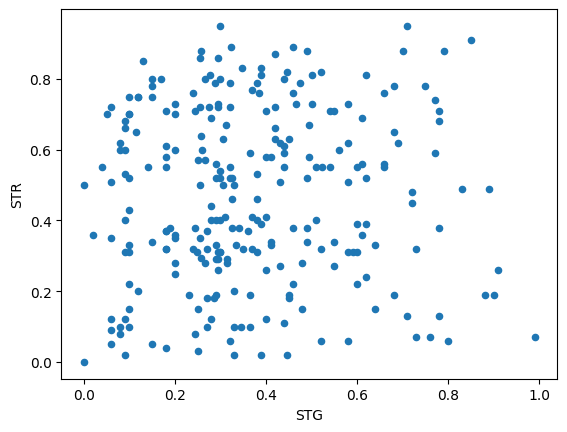

In [ ]:
data.plot(kind='scatter',x='STG', y='STR') # создадим точечную диаграмму
# далее постройте аналогичную диаграмму по petal_length	petal_width

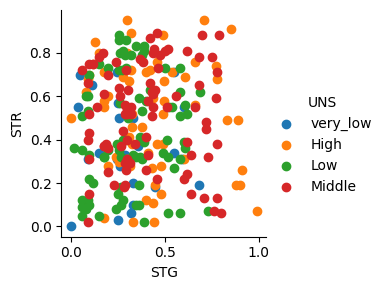

In [ ]:
# используем seaborn FacetGrid чтобы отобразить элементы каждого класса
sns.FacetGrid(data, hue = 'UNS') \
    .map(plt.scatter, 'STG','STR') \
    .add_legend()
# далее постройте аналогичную диаграмму по petal_length	petal_width


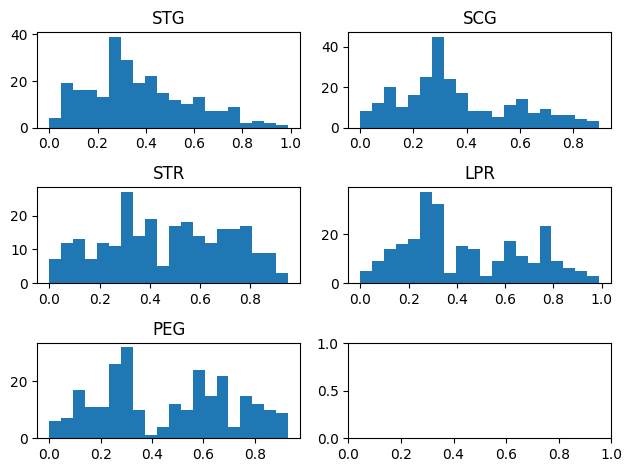

In [ ]:
# Гистограммы по каждому параметру
n_bins = 20
fig, axs = plt.subplots(3, 2)
axs[0,0].hist(data['STG'], bins = n_bins);
axs[0,0].set_title('STG');
axs[0,1].hist(data['SCG'], bins = n_bins);
axs[0,1].set_title('SCG');
axs[1,0].hist(data['STR'], bins = n_bins);
axs[1,0].set_title('STR');
axs[1,1].hist(data['LPR'], bins = n_bins);
axs[1,1].set_title('LPR');
axs[2,0].hist(data['PEG'], bins = n_bins);
axs[2,0].set_title('PEG');

# добавим отступы между диаграммами
fig.tight_layout(pad=1.0);

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   STG     258 non-null    float64
 1   SCG     258 non-null    float64
 2   STR     258 non-null    float64
 3   LPR     258 non-null    float64
 4   PEG     258 non-null    float64
 5   UNS     258 non-null    object 
dtypes: float64(5), object(1)
memory usage: 12.2+ KB


<Axes: xlabel='UNS', ylabel='STG'>

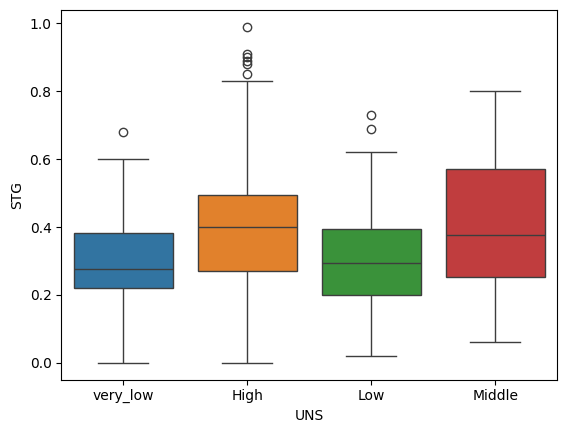

In [ ]:
# Мы можем посмотреть на индивидуальный параметр в Seaborn через коробочную диаграмму.
sns.boxplot(x='UNS', y='STG', hue = 'UNS', data=data)
# Постройте аналогичные диаграммы для остальных полей

<Axes: xlabel='UNS', ylabel='PEG'>

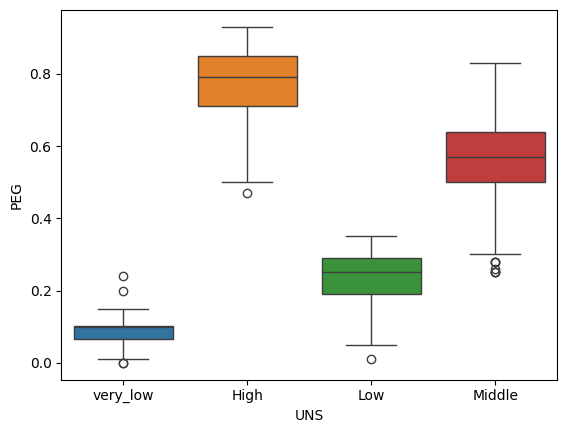

In [ ]:
# Мы можем посмотреть на индивидуальный параметр в Seaborn через коробочную диаграмму.
sns.boxplot(x='UNS', y='PEG', hue = 'UNS', data=data)
# Постройте аналогичные диаграммы для остальных полей

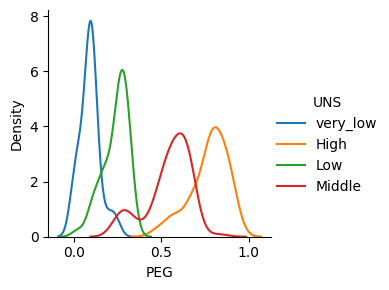

In [ ]:
# Полезным  графиком для изучения одномерных отношений является kdeplot,
# который создает и визуализирует оценку плотности распределения

sns.FacetGrid(data, hue="UNS") \
   .map(sns.kdeplot, "PEG") \
   .add_legend()
# Постройте аналогичные диаграммы для остальных полей

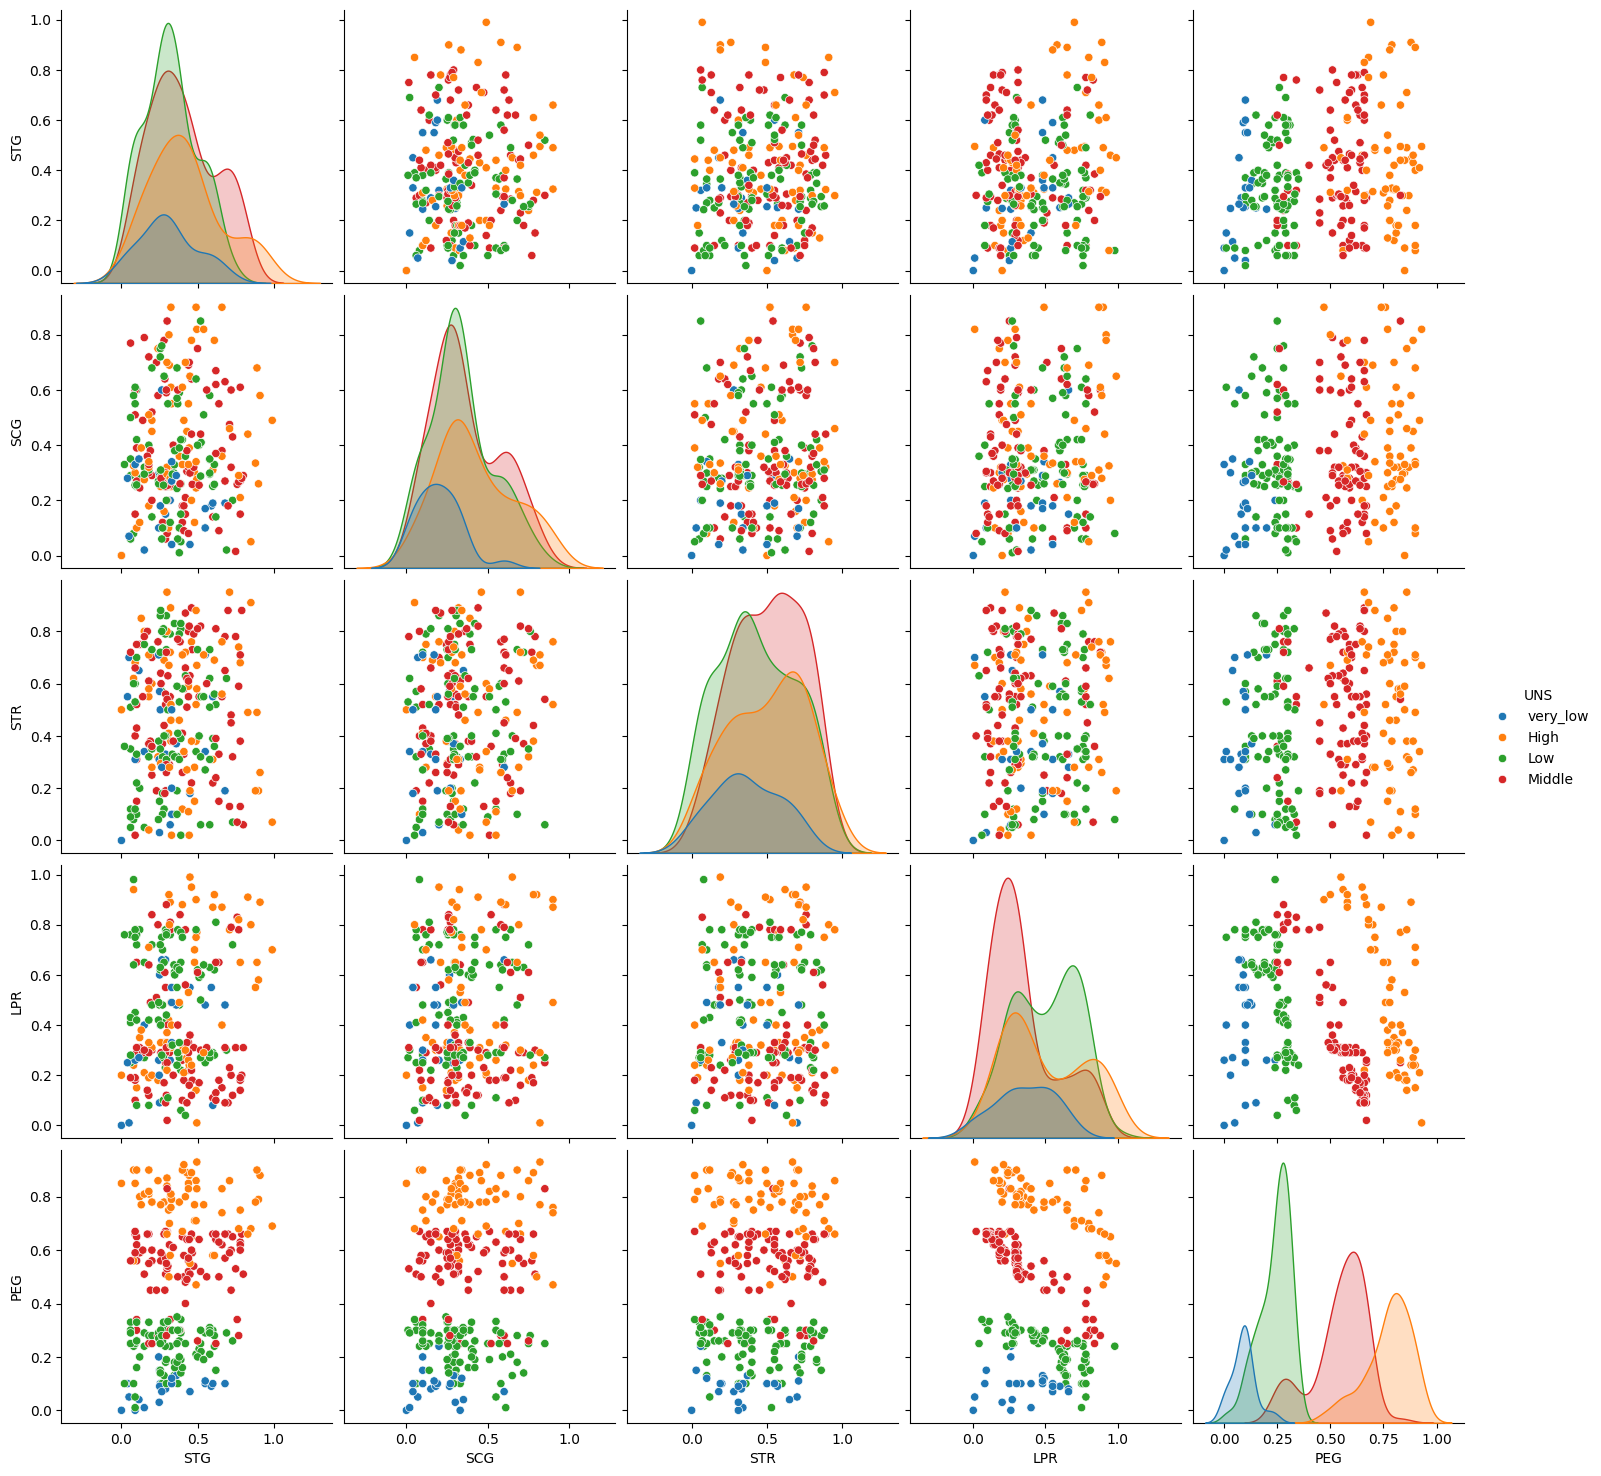

In [ ]:
# двумерная связь
# матрица диаграммы рассеяния
sns.pairplot(data, hue='UNS', size=3)

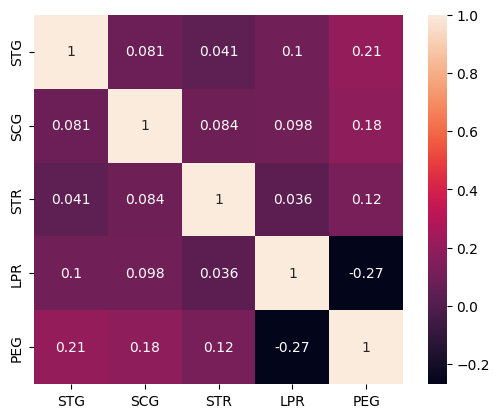

In [ ]:
# Корреляционная матрица
corrmat = data.corr(numeric_only=True)
sns.heatmap(corrmat, annot = True, square = True);